## Update OptiTrack RigidBody definition

This notebook shows how to redefine the local frame of an OptiTrack rigid body while keeping the physical marker layout unchanged.

OptiTrack reports marker positions in the world frame, but rigid-body definitions are stored in the rigid-body local frame. The workflow below follows the standard global-to-local transform idea described in the OptiTrack documentation: build a pose for the new rigid-body frame in world coordinates, then express every marker in that new local frame.

In this example, the new frame is constructed directly from three existing markers. After the transform is computed, the notebook writes a new `.motive` file with marker coordinates expressed in the updated local frame.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import shutil

from robotblockset.tools import get_rbs_path
from robotblockset.tools import normalize
from robotblockset.transformations import rp2t, world2frame
from robotblockset.graphics import plotucs

from robotblockset.optitrack.optitrack_utils import get_rigid_body_markers, set_rigid_body_markers

### Notes on the chosen convention

- `M` contains marker positions read from the original Motive rigid-body file.
- `Tx` will represent the pose of the **new rigid-body frame with respect to the world frame**.
- `world2frame(...)` is then used to convert each marker from world coordinates into coordinates of the new rigid-body frame.

As a result, the object remains physically identical, but the rigid-body origin and axes used by Motive for localization are redefined.

### 1. Load marker positions from the original rigid-body definition

The `.motive` file stores marker positions in the current rigid-body local frame. We load them first so we can visualize the existing geometry and then define a replacement frame.

In [9]:
# Source Motive rigid-body file.
RIGID_BODY_SOURCE = get_rbs_path() + "/examples/WorldBase_ori.motive"

# Marker coordinates from the current rigid-body definition.
M, _, _ = get_rigid_body_markers(RIGID_BODY_SOURCE)

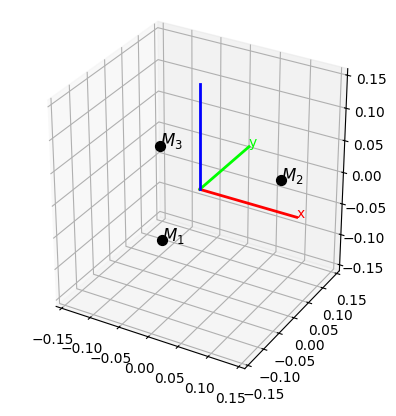

In [10]:
# Visualize the original marker layout.
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
dist = np.max(M)*1.2
plotucs(np.eye(4), UCS_length=dist, UCS_linewidth=2, UCS_labels=["x", "y"])
for i in range(M.shape[0]):
    ax.scatter(*M[i,:], color='black', marker='o', s=50)
    ax.text(*M[i,:], f"$M_{i+1}$", fontsize=12, color='black')

ax.set_aspect("equal", "box")
ax.set_xlim(-dist, dist)
ax.set_ylim(-dist, dist)
ax.set_zlim(-dist, dist)
plt.show()


### 2. Define the new rigid-body frame

The construction below is only one specific example of how the rigid-body frame can be defined. In practice, the origin and axis directions should be chosen to match the application and the intended object-local convention.

Here the new frame is built from three markers:

- the origin is placed at `M[2]`
- the x-axis is aligned with the direction from `M[2]` to `M[1]`
- a second direction from `M[2]` to `M[0]` is used to construct the plane
- the z-axis is obtained by a cross product, and the y-axis is recomputed to make the frame orthonormal

This produces a rigid transform `Tx` describing the new local frame in world coordinates.

In [11]:
# x-axis of the new rigid-body frame.
x = normalize(M[1, :] - M[2, :])

# Auxiliary direction used to define the frame plane.
y1 = normalize(M[0, :] - M[2, :])

# Complete a right-handed orthonormal basis.
z = normalize(np.cross(x, y1))
y = normalize(np.cross(z, x))

# Pose of the new rigid-body frame expressed in the world frame.
Tx = rp2t(np.column_stack((x, y, z)), M[2, :])

### 3. Express all markers in the new local frame

This is the key step. Each marker is transformed from world coordinates into the coordinate system of the newly defined rigid-body frame. These transformed coordinates are what must be written back to the Motive file.

In [12]:
# Convert each marker from world coordinates to the new rigid-body frame.
Mx = np.array([world2frame(M[i, :], Tx) for i in range(M.shape[0])])

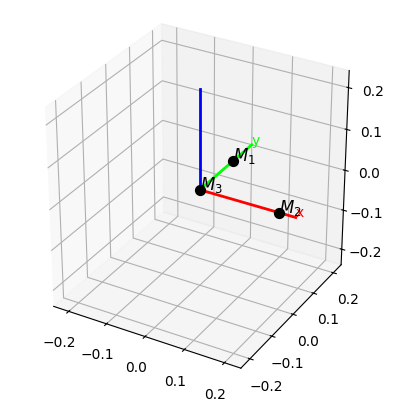

In [13]:
# Visualize marker coordinates after the change of rigid-body frame.
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
dist = np.max(Mx)*1.2
plotucs(np.eye(4), UCS_length=dist, UCS_linewidth=2, UCS_labels=["x", "y"])
for i in range(Mx.shape[0]):
    ax.scatter(*Mx[i,:], color='black', marker='o', s=50)
    ax.text(*Mx[i,:], f"$M_{i+1}$", fontsize=12, color='black')

ax.set_aspect("equal", "box")
ax.set_xlim(-dist, dist)
ax.set_ylim(-dist, dist)
ax.set_zlim(-dist, dist)
plt.show()

### 4. Save the updated rigid-body definition

A copy of the original file is created first. The copied file is then updated with `Mx`, not `M`, because Motive expects marker positions in the rigid-body local frame. Writing `Mx` redefines the rigid-body origin and axes while preserving the same physical marker arrangement.

Make a copy of the original rigid-body definition file and save the transformed marker coordinates into the new file.

In [14]:
# Destination Motive file with the updated rigid-body frame definition.
RIGID_BODY_DESTINATION = "WorldBase_new.motive"

# Keep the original file unchanged.
shutil.copy(RIGID_BODY_SOURCE, RIGID_BODY_DESTINATION)

# Write marker coordinates expressed in the new rigid-body frame.
set_rigid_body_markers(RIGID_BODY_DESTINATION, Mx)